#Name: Aliza Lama
#Student ID:2408583
#Exercise: Build a Denoising Convolutional Autoencoder
#Dataset: Devnagari Handwritten Digit Dataset:

In [9]:
import os
import numpy as np
from PIL import Image

def load_images(data_path):
    images = []

    for root, dirs, files in os.walk(data_path):
        for file in files:
            img_path = os.path.join(root, file)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((32, 32))
                img = np.array(img)
                images.append(img)
            except:
                continue

    return np.array(images)

train_path = "/content/drive/MyDrive/AI&ML/DevanagariHandwrittenDigitDataset/Train"
test_path = "/content/drive/MyDrive/AI&ML/DevanagariHandwrittenDigitDataset/Test"

x_train = load_images(train_path)
x_test = load_images(test_path)

print(x_train.shape, x_test.shape)

(17000, 32, 32) (3000, 32, 32)


#2.2 Normalize + Reshape

In [10]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

#2.3 Add Noise

In [11]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

#2.4 Build Autoencoder

In [12]:
from tensorflow.keras import layers, models

input_img = layers.Input(shape=(32, 32, 1))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#2.5 Train

In [13]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 104s 374ms/step - loss: 0.2914 - val_loss: 0.1967
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 98s 368ms/step - loss: 0.1826 - val_loss: 0.1720
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 98s 367ms/step - loss: 0.1670 - val_loss: 0.1676
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 145s 378ms/step - loss: 0.1599 - val_loss: 0.1571
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 99s 374ms/step - loss: 0.1554 - val_loss: 0.1544
Epoch 6/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 99s 372ms/step - loss: 0.1528 - val_loss: 0.1512
Epoch 7/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 145s 383ms/step - loss: 0.1504 - val_loss: 0.1500
Epoch 8/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 101s 379ms/step - loss: 0.1484 - val_loss: 0.1488
Epoch 9/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 98s 369ms/step - loss: 0.1472 - val_loss: 0.1479
Epoch 10/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 103s 388ms/step - loss: 0.1457 - val_loss: 0.1464
Epoch 11/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 136s 364ms/step - loss: 0.1447 - val_loss: 0.1478
Epoch 12/20
2

#2.6 Loss Graph

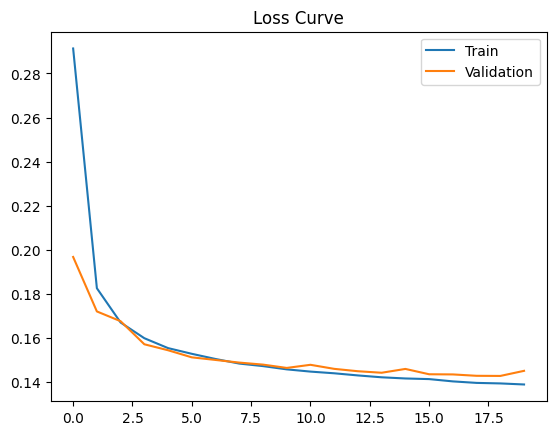

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(["Train", "Validation"])
plt.show()

#2.7 Results Visualization

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


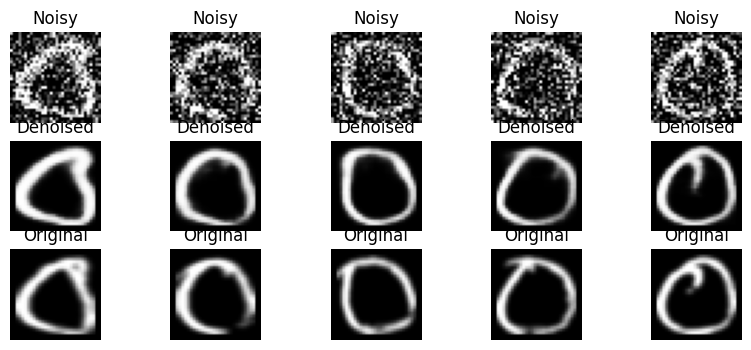

In [15]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(10,4))

for i in range(n):
    # Noisy
    plt.subplot(3, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(32,32), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    plt.subplot(3, n, i+1+n)
    plt.imshow(decoded_imgs[i].reshape(32,32), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    # Original
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(x_test[i].reshape(32,32), cmap='gray')
    plt.title("Original")
    plt.axis("off")

plt.show()